## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

# Imports

In [2]:
from sokoban import Map, save_images, create_gif
import time
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing

# Test LRTA* solver

Testing LRTA* solver:
Solution found with 4319 moves
Pull moves used: 892
Time taken: 0.35 seconds

Initial state:


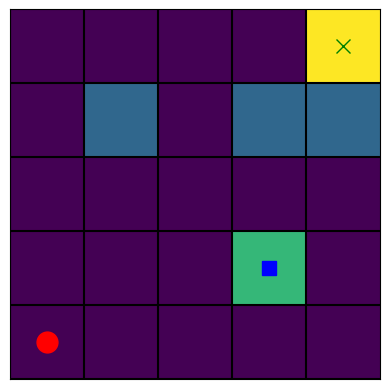


Final state:


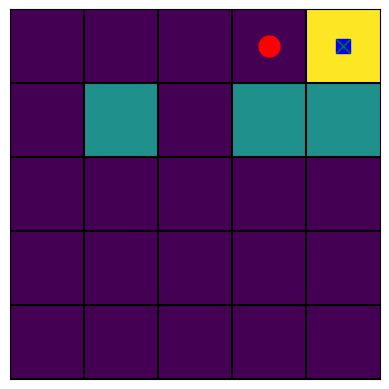

In [18]:
sokoban_map = Map.from_yaml('tests/easy_map1.yaml')
print("Testing LRTA* solver:")
lrta_solver = LRTAStar(max_iterations=10000)
start_time = time.time()
solution = lrta_solver.solve(sokoban_map)
solve_time = time.time() - start_time
if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after LRTA*
    final_state = Map.from_yaml('tests/easy_map1.yaml')
    for move in solution:
        final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'lrta_solution.png')

# Test Simulated Annealing solver

Solution found with 1895 moves
Pull moves used: 463
Time taken: 0.31 seconds

Initial state:


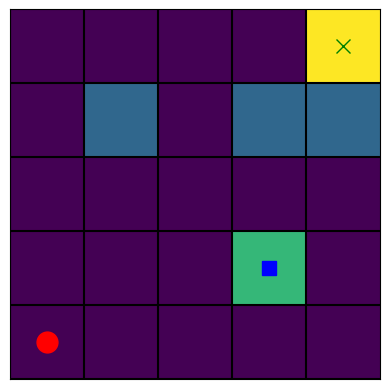


Final state:


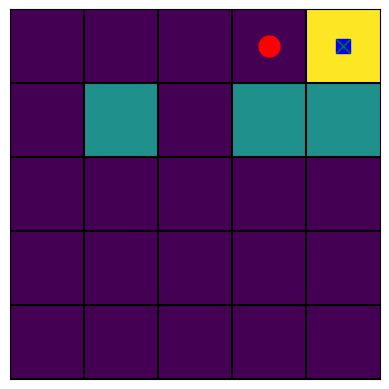

In [11]:
sa_solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)
start_time = time.time()
sokoban_map = Map.from_yaml('tests/easy_map1.yaml')
solution = sa_solver.solve(sokoban_map)
solve_time = time.time() - start_time

if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after Simulated Annealing
    final_state = Map.from_yaml('tests/easy_map1.yaml')
    for move in solution:
        final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'sa_solution.png')

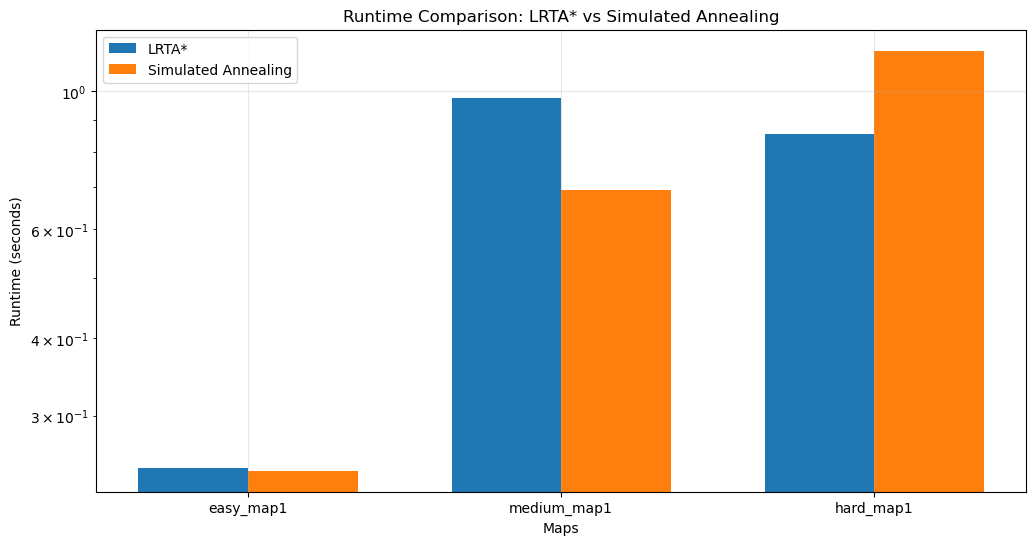

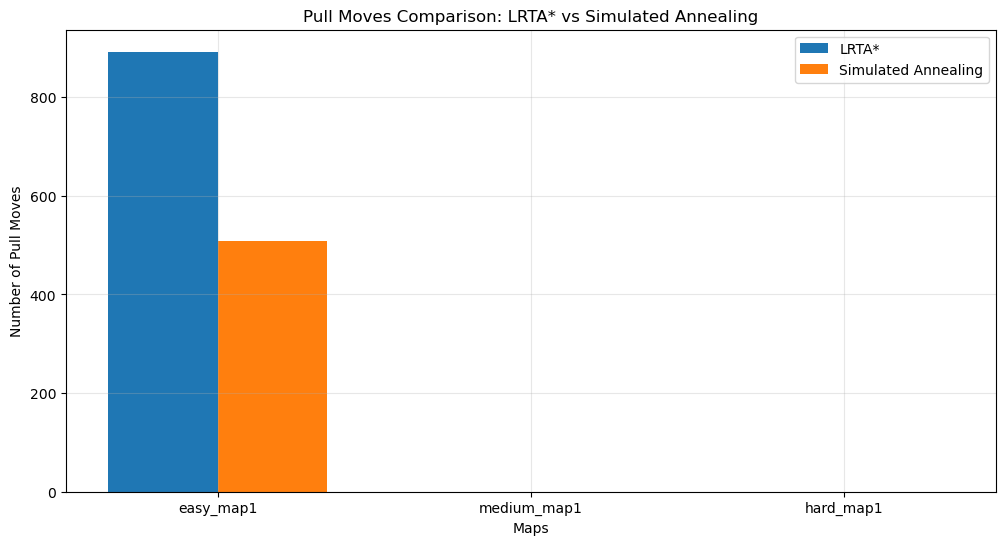


Detailed Statistics:
--------------------------------------------------

Map: easy_map1
LRTA*:
  Time: 0.25 seconds
  Total moves: 4319
  Pull moves: 892
  Solved: True

Simulated Annealing:
  Time: 0.24 seconds
  Total moves: 1967
  Pull moves: 507
  Solved: True

Map: medium_map1
LRTA*:
  Time: 0.98 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Simulated Annealing:
  Time: 0.69 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Map: hard_map1
LRTA*:
  Time: 0.85 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Simulated Annealing:
  Time: 1.16 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False


In [12]:
# Import required libraries for analysis
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os

# Create a function to run tests and collect metrics
def run_analysis(solver, map_files, heuristics=None):
    results = defaultdict(dict)

    for map_file in map_files:
        map_name = os.path.basename(map_file).replace('.yaml', '')
        sokoban_map = Map.from_yaml(map_file)

        # Run solver
        start_time = time.time()
        solution = solver.solve(sokoban_map)
        solve_time = time.time() - start_time

        # Collect metrics
        results[map_name] = {
            'time': solve_time,
            'moves': len(solution) if solution else 0,
            'pull_moves': sum(1 for move in solution if move >= 4) if solution else 0,
            'solved': solution is not None
        }

    return results

# List of test maps
test_maps = [
    'tests/easy_map1.yaml',
    'tests/medium_map1.yaml',
    'tests/hard_map1.yaml'
]

# Run analysis for both solvers
lrta_solver = LRTAStar(max_iterations=10000)
sa_solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)

lrta_results = run_analysis(lrta_solver, test_maps)
sa_results = run_analysis(sa_solver, test_maps)

# Create bar plot for solution times
plt.figure(figsize=(12, 6))
maps = list(lrta_results.keys())
lrta_times = [lrta_results[m]['time'] for m in maps]
sa_times = [sa_results[m]['time'] for m in maps]

x = np.arange(len(maps))
width = 0.35

plt.bar(x - width/2, lrta_times, width, label='LRTA*')
plt.bar(x + width/2, sa_times, width, label='Simulated Annealing')

plt.xlabel('Maps')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime Comparison: LRTA* vs Simulated Annealing')
plt.xticks(x, maps)
plt.legend()
plt.yscale('log')  # Use log scale for better visualization
plt.grid(True, alpha=0.3)
plt.show()

# Create bar plot for pull moves
plt.figure(figsize=(12, 6))
lrta_pulls = [lrta_results[m]['pull_moves'] for m in maps]
sa_pulls = [sa_results[m]['pull_moves'] for m in maps]

plt.bar(x - width/2, lrta_pulls, width, label='LRTA*')
plt.bar(x + width/2, sa_pulls, width, label='Simulated Annealing')

plt.xlabel('Maps')
plt.ylabel('Number of Pull Moves')
plt.title('Pull Moves Comparison: LRTA* vs Simulated Annealing')
plt.xticks(x, maps)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print("-" * 50)
for map_name in maps:
    print(f"\nMap: {map_name}")
    print("LRTA*:")
    print(f"  Time: {lrta_results[map_name]['time']:.2f} seconds")
    print(f"  Total moves: {lrta_results[map_name]['moves']}")
    print(f"  Pull moves: {lrta_results[map_name]['pull_moves']}")
    print(f"  Solved: {lrta_results[map_name]['solved']}")

    print("\nSimulated Annealing:")
    print(f"  Time: {sa_results[map_name]['time']:.2f} seconds")
    print(f"  Total moves: {sa_results[map_name]['moves']}")
    print(f"  Pull moves: {sa_results[map_name]['pull_moves']}")
    print(f"  Solved: {sa_results[map_name]['solved']}")